In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib as mpl

mpl.rcParams['svg.fonttype'] = 'none'
mpl.rcParams['font.family'] = 'Arial'
sns.set_style("ticks")

In [2]:
import pickle as pkl

cluster_edges_path = '../cluster_edges/mousebrain.pkl' # remember to change this
with open(cluster_edges_path, 'rb') as f:
    cluster_edges = pkl.load(f)
cluster_edges

[('Isocortex L6', 'Isocortex L5'),
 ('Isocortex L5', 'Isocortex L4'),
 ('Isocortex L4', 'Isocortex L2/3'),
 ('Isocortex L2/3', 'HIP & CTXpl L1')]

In [4]:
import re
import ast
import os

In [5]:
k = 5
data = 'mousebrain_revised'
basis = 'spatial'
metric_name = 'gen_cbdir_edge'
models = ['scvelo', 'velovi', 'unitvelo', 'velovae', 'deepvelo_cui', 'topovelo', 'stt']
results = {}
for cluster_edge in cluster_edges:
    edge = f'{cluster_edge[0]} -> {cluster_edge[1]}'
    result = {'k': range(k)}
    for model in models: 
        model_name = model if model != 'scvelo' else 'scvelo_dynamical'
        # metric_file = f'../logs/{data}/{model}/metric_{basis}_redo.csv'
        metric_file = f'../logs/{model}/real/{data}/metric_{basis}_redo.csv'
        if not os.path.exists(metric_file):
            metric_file = f'../logs/{model}/real/{data}/metric_{basis}.csv'
        metric = pd.read_csv(metric_file)
        metric.set_index('Unnamed: 0', inplace=True)
        idx_name = f'{metric_name}_{model_name}_velocity_{edge}'
        if idx_name in metric.index:
            cbdir = metric.loc[metric.index == idx_name, '0'].values[0]
            if 'nan' not in cbdir:
                cbdir = re.sub(r'\s+', ', ', cbdir)
                cbdir = ast.literal_eval(cbdir)
                result[model] = cbdir
        if model == 'stt': 
            stt_idx_name = f'{metric_name}_vj_{edge}'
            if stt_idx_name in metric.index:
                cbdir = metric.loc[metric.index == stt_idx_name, '0'].values[0]
                if 'nan' not in cbdir:
                    cbdir = re.sub(r'\s+', ', ', cbdir)
                    cbdir = ast.literal_eval(cbdir)
                    result['stt_vj'] = cbdir
    results[edge] = result
results

{'Isocortex L6 -> Isocortex L5': {'k': range(0, 5),
  'scvelo': [0.05981087, 0.23732095, 0.7038676, 0.81311565, 0.83922437],
  'velovi': [-0.11039035, 0.03722537, 0.47513418, 0.59087932, 0.62143952],
  'unitvelo': [-0.08776158, 0.10405793, 0.49369825, 0.59672842, 0.62064785],
  'velovae': [0.02385867, 0.04971022, 0.34012542, 0.54927672, 0.62022991],
  'deepvelo_cui': [0.1247634, 0.14985588, 0.35843771, 0.55299402, 0.64314932],
  'topovelo': [-0.02949245, 0.00416392, 0.28889159, 0.51761843, 0.5897362],
  'stt': [0.07139718, 0.30448547, 0.65526852, 0.7182393, 0.73298386],
  'stt_vj': [-0.24054774, -0.23245165, -0.05330308, 0.1792511, 0.31914576]},
 'Isocortex L5 -> Isocortex L4': {'k': range(0, 5),
  'scvelo': [0.14150178, 0.28327095, 0.67253166, 0.73347704, 0.73755075],
  'velovi': [-0.09012548, 0.03298099, 0.37222931, 0.4402385, 0.44650683],
  'unitvelo': [0.07146494, 0.13058419, 0.43087775, 0.49256589, 0.4974398],
  'velovae': [0.00265251, 0.06058051, 0.33661753, 0.47129332, 0.5114494

In [6]:
model_colors = {
    "scvelo": "#1f77b4",
    "scvelo_avg": "#02ccfe",
    "velovae": "#d62728",
    "topovelo": "#2ca02c",
    "velovi": "#ff7f0e",
    "unitvelo": "#9467bd",
    "deepvelo_cui": "#8c564b",
    "stt": "#e377c2",
    "stt_vj": "#cd8c95"
}

In [7]:
import os
save_dir = f'../results/results_0128/{data}/metrics'
os.makedirs(save_dir, exist_ok=True)

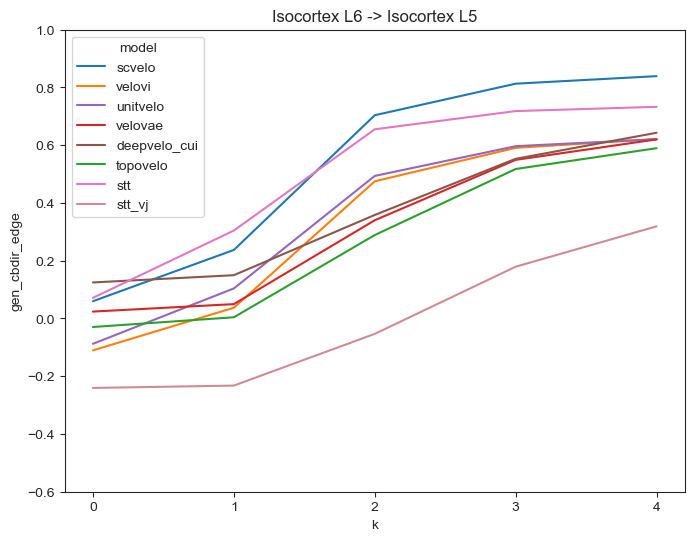

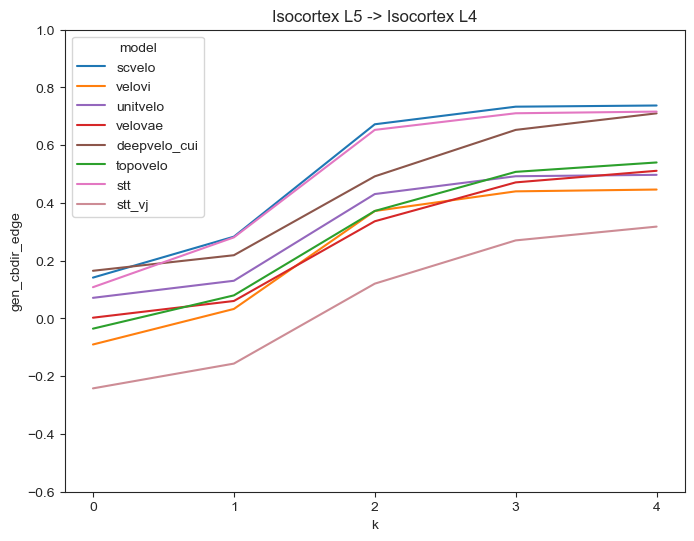

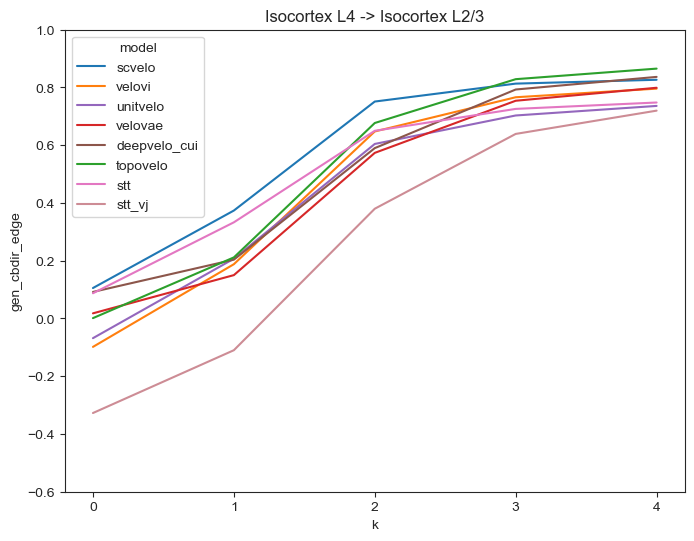

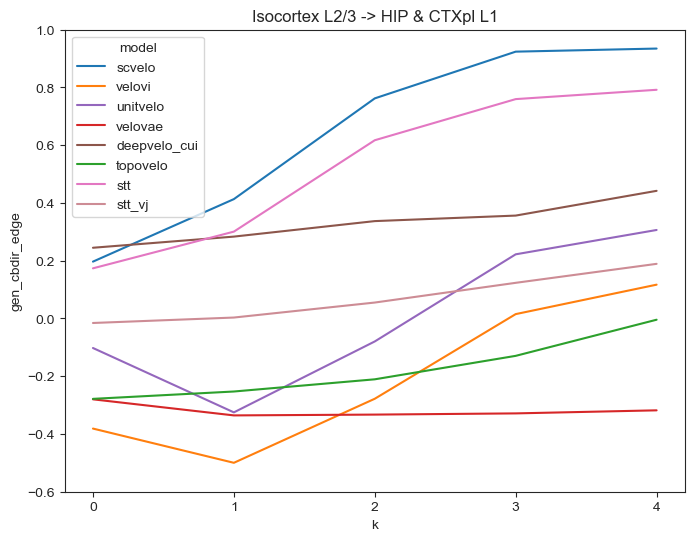

In [12]:
for key, value in results.items():
    df = pd.DataFrame(value).melt(id_vars='k', var_name='model', value_name=metric_name)
    plt.figure(figsize=(8, 6))
    sns.lineplot(data=df, x='k', y=metric_name, hue='model', palette=model_colors)
    plt.ylim(-0.6, 1) # remember to change this
    plt.xticks(range(k))
    plt.title(key)
    plt.savefig(f'{save_dir}/{metric_name}_{key.replace(" -> ", "_").replace(" ", "_").replace("/", "_")}.svg')
    plt.show()